In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, r2_score
import os

DATA_PROC = os.path.join('..', 'data', 'processed')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv(os.path.join(DATA_PROC, 'dataset_maestro.csv'), parse_dates=['fecha'])

print(f"Dataset cargado: {df.shape}")
print(f"Nulos: {df.isnull().sum().sum()}")

Dataset cargado: (1827, 34)
Nulos: 0


In [46]:
# Variable dependiente: ventas netas diarias (Yt del PDF)
TARGET = 'venta_neta_eur'

# Excluimos columnas que no son features del modelo
EXCLUIR = ['fecha', 'venta_neta_eur', 'unidades', 'num_lineas', 'anio']

FEATURES = [c for c in df.columns if c not in EXCLUIR]

print(f"Features totales: {len(FEATURES)}")
print("\nVariables de CALENDARIO (exógenas Ct,j):")
cal_vars = [f for f in FEATURES if f not in 
            [c for c in FEATURES if 'ads_' in c or 'sesion' in c 
             or 'visita' in c or 'pedidos_online' in c or 'conv_' in c]]
for v in cal_vars:
    print(f"  {v}")

print("\nVariables de TRÁFICO:")
traf_vars = [f for f in FEATURES if any(x in f for x in 
             ['sesiones', 'visitas', 'pedidos_online', 'conv_'])]
for v in traf_vars:
    print(f"  {v}")

print("\nVariables de ADSTOCK (At,m del PDF):")
ads_vars = [f for f in FEATURES if 'ads_' in f]
for v in ads_vars:
    print(f"  {v}")

Features totales: 29

Variables de CALENDARIO (exógenas Ct,j):
  fin_de_semana
  payday_flag
  rebajas_flag
  black_friday_flag
  navidad_flag
  semana_santa_flag
  vacaciones_flag
  festivo_local_flag
  temperatura_media_c
  lluvia_indice
  turismo_indice
  incidencia_ecommerce
  tendencia
  dummy_anio_2021
  dummy_anio_2022
  dummy_anio_2023
  dummy_anio_2024

Variables de TRÁFICO:
  sesiones_web
  pedidos_online
  visitas_tienda
  conv_web_pct

Variables de ADSTOCK (At,m del PDF):
  ads_display
  ads_email_crm
  ads_exterior
  ads_paid_search
  ads_prensa
  ads_radio_local
  ads_social_paid
  ads_video_online


In [47]:
# Usamos split temporal, NO aleatorio — en series temporales el orden importa
# Train: 2020-2023  |  Test: 2024
FECHA_CORTE = '2024-01-01'

train = df[df['fecha'] <  FECHA_CORTE].copy()
test  = df[df['fecha'] >= FECHA_CORTE].copy()

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train: {len(train)} días  ({train['fecha'].min().date()} → {train['fecha'].max().date()})")
print(f"Test:  {len(test)}  días  ({test['fecha'].min().date()}  → {test['fecha'].max().date()})")
print(f"Features: {len(FEATURES)}")

Train: 1461 días  (2020-01-01 → 2023-12-31)
Test:  366  días  (2024-01-01  → 2024-12-31)
Features: 29


In [48]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("✓ Random Forest entrenado")

# Evaluación
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

mape_train = mean_absolute_percentage_error(y_train, y_pred_train) * 100
mape_test  = mean_absolute_percentage_error(y_test,  y_pred_test)  * 100
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print(f"\n{'':30} {'TRAIN':>10} {'TEST':>10}")
print(f"{'MAPE (%)':30} {mape_train:>10.2f} {mape_test:>10.2f}")
print(f"{'R² Score':30} {r2_train:>10.4f} {r2_test:>10.4f}")
print(f"\nObjetivo del PDF: MAPE ~12% → nuestro modelo: {mape_test:.1f}%")

✓ Random Forest entrenado

                                    TRAIN       TEST
MAPE (%)                             1.02      11.23
R² Score                           0.9967   -56.6051

Objetivo del PDF: MAPE ~12% → nuestro modelo: 11.2%


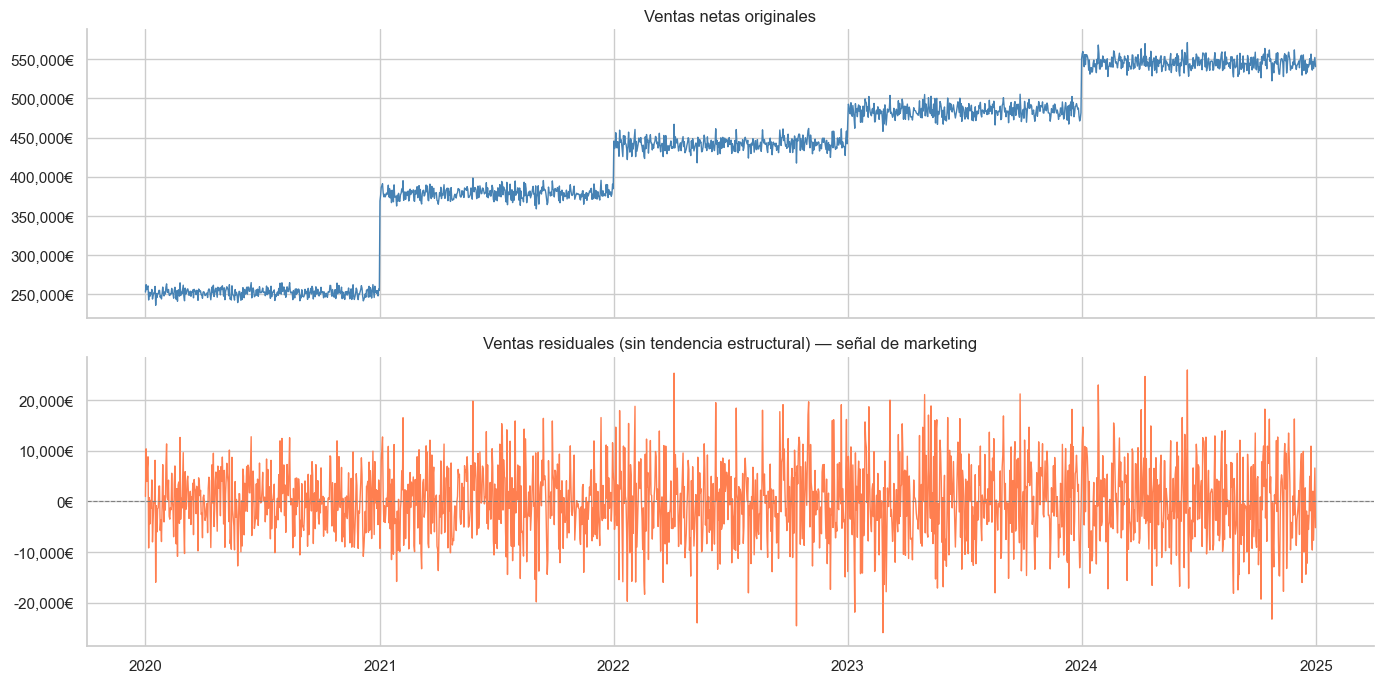

Varianza explicada por tendencia+dummies: 99.5%
Ventas residuales — media: -0€  std: 7,276€


In [49]:
from sklearn.linear_model import LinearRegression

# Paso 1: ajustamos un modelo lineal simple solo con tendencia y dummies de año
# para extraer el componente estructural
tendencia_vars = ['tendencia', 'dummy_anio_2021', 'dummy_anio_2022',
                  'dummy_anio_2023', 'dummy_anio_2024']

reg_tendencia = LinearRegression()
reg_tendencia.fit(df[tendencia_vars], df[TARGET])

# Paso 2: ventas residuales = ventas reales - componente estructural
df['venta_tendencia']  = reg_tendencia.predict(df[tendencia_vars])
df['venta_residual']   = df[TARGET] - df['venta_tendencia']

# Visualizamos
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df['fecha'], df[TARGET],           color='steelblue', linewidth=1)
axes[0].set_title('Ventas netas originales')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

axes[1].plot(df['fecha'], df['venta_residual'], color='coral', linewidth=1)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('Ventas residuales (sin tendencia estructural) — señal de marketing')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))

plt.tight_layout()
plt.show()

print(f"Varianza explicada por tendencia+dummies: "
      f"{reg_tendencia.score(df[tendencia_vars], df[TARGET])*100:.1f}%")
print(f"Ventas residuales — media: {df['venta_residual'].mean():,.0f}€  "
      f"std: {df['venta_residual'].std():,.0f}€")

In [50]:
# Features: excluimos tendencia y dummies (ya fueron usadas para extraer el escalón)
FEATURES_RESID = [c for c in FEATURES 
                  if c not in tendencia_vars + ['tendencia']]

train_r = df[df['fecha'] <  FECHA_CORTE].copy()
test_r  = df[df['fecha'] >= FECHA_CORTE].copy()

X_train_r = train_r[FEATURES_RESID]
y_train_r = train_r['venta_residual']
X_test_r  = test_r[FEATURES_RESID]
y_test_r  = test_r['venta_residual']

rf_resid = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_resid.fit(X_train_r, y_train_r)

mape_r_train = mean_absolute_percentage_error(
    y_train_r + train_r['venta_tendencia'],
    rf_resid.predict(X_train_r) + train_r['venta_tendencia']
) * 100
mape_r_test = mean_absolute_percentage_error(
    y_test_r + test_r['venta_tendencia'],
    rf_resid.predict(X_test_r) + test_r['venta_tendencia']
) * 100

print(f"RF sobre residuos — MAPE train: {mape_r_train:.2f}%  |  MAPE test: {mape_r_test:.2f}%")

# Nueva importancia
imp_resid = pd.DataFrame({
    'feature':    FEATURES_RESID,
    'importance': rf_resid.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

imp_resid['importancia_pct'] = (imp_resid['importance'] * 100).round(2)
imp_resid['acumulada_pct']   = imp_resid['importancia_pct'].cumsum().round(2)

display(imp_resid.head(20))

RF sobre residuos — MAPE train: 1.25%  |  MAPE test: 1.25%


,feature,importance,importancia_pct,acumulada_pct
0,turismo_indice,0.106840,10.68,10.68
1,lluvia_indice,0.106031,10.60,21.28
2,ads_video_online,0.083064,8.31,29.59
3,conv_web_pct,0.066934,6.69,36.28
4,ads_display,0.064921,6.49,42.77
5,ads_email_crm,0.062837,6.28,49.05
6,sesiones_web,0.062104,6.21,55.26
7,temperatura_media_c,0.062052,6.21,61.47
8,ads_prensa,0.059963,6.00,67.47
9,ads_exterior,0.059380,5.94,73.41


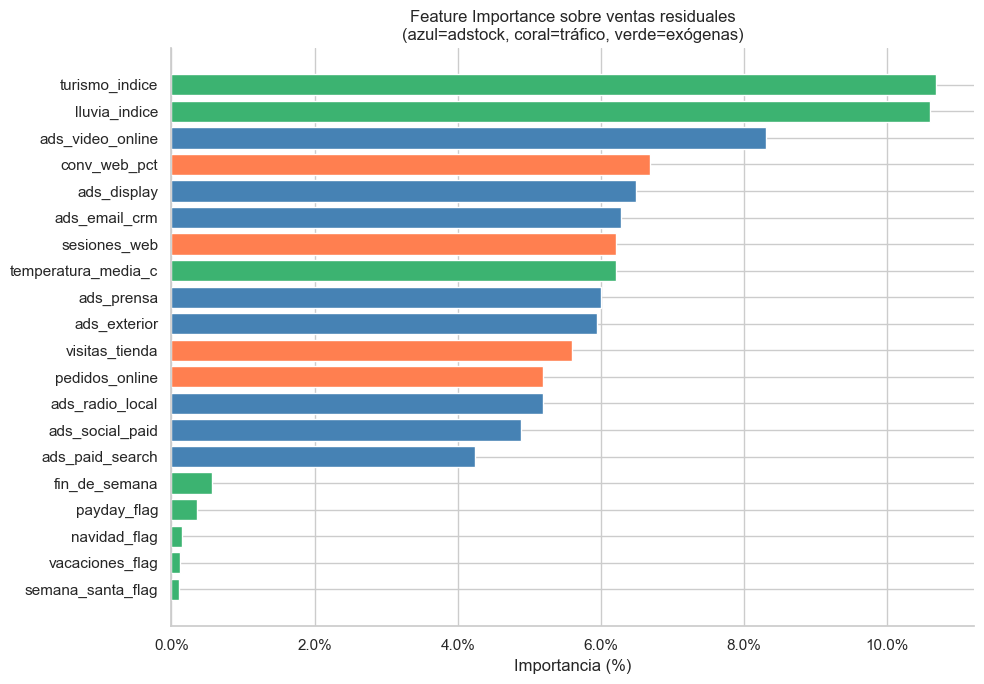


Variables seleccionadas sobre residuos: 14
  turismo_indice                      10.68%
  lluvia_indice                       10.60%
  ads_video_online                    8.31%
  conv_web_pct                        6.69%
  ads_display                         6.49%
  ads_email_crm                       6.28%
  sesiones_web                        6.21%
  temperatura_media_c                 6.21%
  ads_prensa                          6.00%
  ads_exterior                        5.94%
  visitas_tienda                      5.59%
  pedidos_online                      5.19%
  ads_radio_local                     5.19%
  ads_social_paid                     4.89%

✓ Variables actualizadas guardadas


In [51]:
fig, ax = plt.subplots(figsize=(10, 7))
top = imp_resid.head(20)
colores = ['steelblue'     if 'ads_' in f
           else 'coral'    if any(x in f for x in ['sesiones','visitas','pedidos_online','conv_'])
           else 'mediumseagreen'
           for f in top['feature']]

ax.barh(top['feature'][::-1], top['importancia_pct'][::-1], color=colores[::-1])
ax.set_xlabel('Importancia (%)')
ax.set_title('Feature Importance sobre ventas residuales\n(azul=adstock, coral=tráfico, verde=exógenas)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

# Variables seleccionadas con umbral 95%
vars_resid_sel = imp_resid[imp_resid['acumulada_pct'] <= 95]['feature'].tolist()
print(f"\nVariables seleccionadas sobre residuos: {len(vars_resid_sel)}")
for v in vars_resid_sel:
    pct = imp_resid[imp_resid['feature']==v]['importancia_pct'].values[0]
    print(f"  {v:<35} {pct:.2f}%")

# Guardamos versión actualizada
imp_resid.to_csv(os.path.join(DATA_PROC, 'variables_seleccionadas.csv'), index=False)
print("\n✓ Variables actualizadas guardadas")

TOP 20 variables por importancia:


,feature,importance,importancia_pct,acumulada_pct
0,tendencia,0.541840,54.18,54.18
1,dummy_anio_2021,0.371127,37.11,91.29
2,dummy_anio_2022,0.068323,6.83,98.12
3,dummy_anio_2023,0.015353,1.54,99.66
4,turismo_indice,0.000338,0.03,99.69
5,lluvia_indice,0.000283,0.03,99.72
6,ads_email_crm,0.000276,0.03,99.75
7,visitas_tienda,0.000260,0.03,99.78
8,temperatura_media_c,0.000242,0.02,99.80
9,pedidos_online,0.000235,0.02,99.82


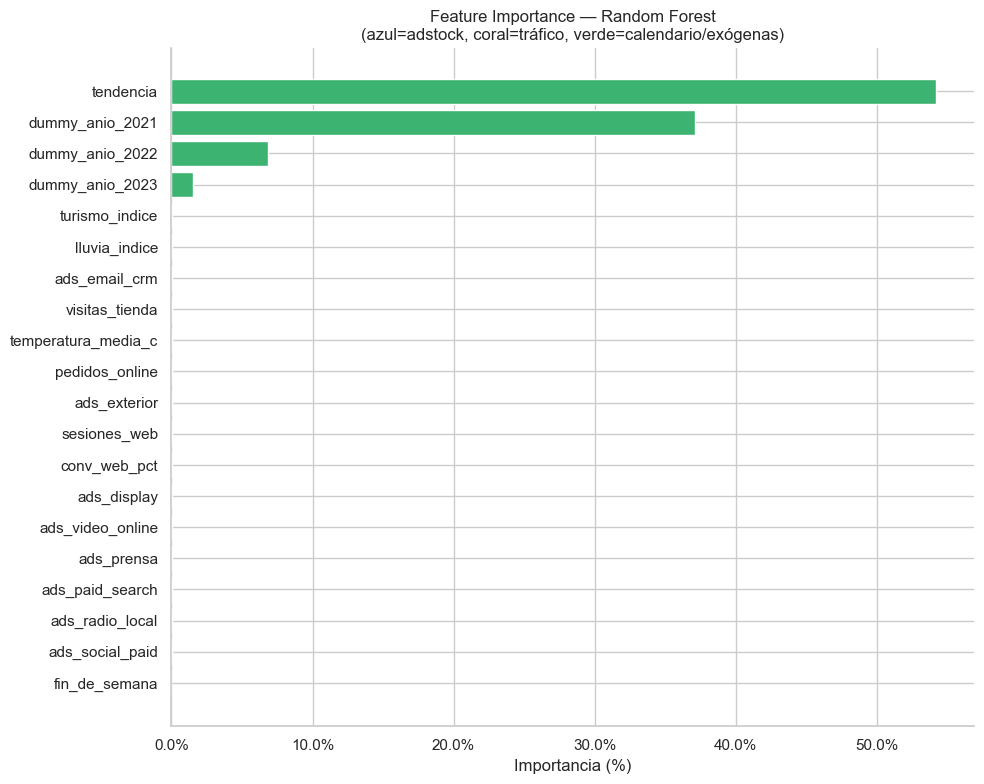

In [52]:
importances = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importances['importancia_pct'] = (importances['importance'] * 100).round(2)
importances['acumulada_pct']   = importances['importancia_pct'].cumsum().round(2)

print("TOP 20 variables por importancia:")
display(importances.head(20))

# Gráfico
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importances.head(20)
colores = ['steelblue' if 'ads_' in f 
           else 'coral'    if any(x in f for x in ['sesiones','visitas','pedidos_online','conv_'])
           else 'mediumseagreen' 
           for f in top20['feature']]

ax.barh(top20['feature'][::-1], top20['importancia_pct'][::-1], color=colores[::-1])
ax.set_xlabel('Importancia (%)')
ax.set_title('Feature Importance — Random Forest\n(azul=adstock, coral=tráfico, verde=calendario/exógenas)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.tight_layout()
plt.show()

In [53]:
# Umbral: mantenemos variables que explican el 95% acumulado de importancia
UMBRAL_ACUM = 95.0

vars_seleccionadas = importances[importances['acumulada_pct'] <= UMBRAL_ACUM]['feature'].tolist()

# Siempre incluimos las dummies de año (capturan el escalón estructural)
dummies_anio = [f for f in FEATURES if 'dummy_anio' in f]
for d in dummies_anio:
    if d not in vars_seleccionadas:
        vars_seleccionadas.append(d)

# Variables descartadas
vars_descartadas = [f for f in FEATURES if f not in vars_seleccionadas]

print(f"Variables SELECCIONADAS ({len(vars_seleccionadas)}):")
for v in vars_seleccionadas:
    imp = importances[importances['feature'] == v]['importancia_pct'].values[0]
    print(f"  {v:<35} {imp:.2f}%")

print(f"\nVariables DESCARTADAS ({len(vars_descartadas)}):")
for v in vars_descartadas:
    imp = importances[importances['feature'] == v]['importancia_pct'].values[0]
    print(f"  {v:<35} {imp:.2f}%")

Variables SELECCIONADAS (5):
  tendencia                           54.18%
  dummy_anio_2021                     37.11%
  dummy_anio_2022                     6.83%
  dummy_anio_2023                     1.54%
  dummy_anio_2024                     0.00%

Variables DESCARTADAS (24):
  fin_de_semana                       0.00%
  payday_flag                         0.00%
  rebajas_flag                        0.00%
  black_friday_flag                   0.00%
  navidad_flag                        0.00%
  semana_santa_flag                   0.00%
  vacaciones_flag                     0.00%
  festivo_local_flag                  0.00%
  temperatura_media_c                 0.02%
  lluvia_indice                       0.03%
  turismo_indice                      0.03%
  incidencia_ecommerce                0.00%
  sesiones_web                        0.02%
  pedidos_online                      0.02%
  visitas_tienda                      0.03%
  conv_web_pct                        0.02%
  ads_display   

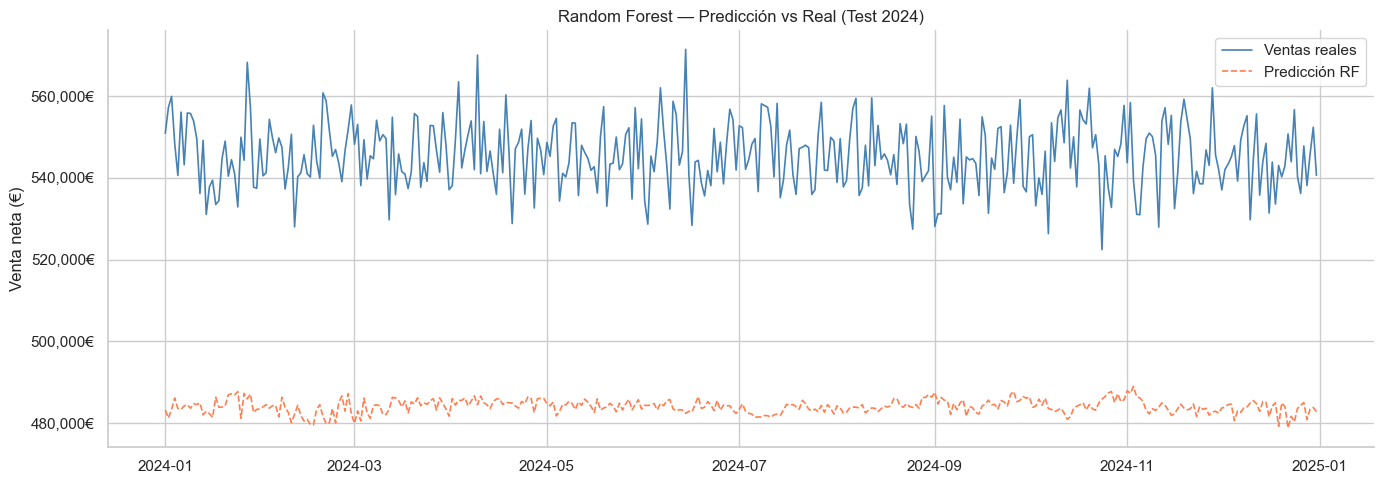

In [54]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test['fecha'], y_test,       label='Ventas reales',    color='steelblue', linewidth=1.2)
ax.plot(test['fecha'], y_pred_test,  label='Predicción RF',    color='coral',     linewidth=1.2, linestyle='--')
ax.set_title('Random Forest — Predicción vs Real (Test 2024)')
ax.set_ylabel('Venta neta (€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
ax.legend()
plt.tight_layout()
plt.show()

In [55]:
vars_df = pd.DataFrame({
    'feature':        vars_seleccionadas,
    'importancia_pct': [importances[importances['feature'] == v]['importancia_pct'].values[0] 
                        for v in vars_seleccionadas]
}).sort_values('importancia_pct', ascending=False)

vars_df.to_csv(os.path.join(DATA_PROC, 'variables_seleccionadas.csv'), index=False)
print(f"✓ Variables seleccionadas guardadas: {len(vars_seleccionadas)} features")
print(f"  Archivo: data/processed/variables_seleccionadas.csv")

✓ Variables seleccionadas guardadas: 5 features
  Archivo: data/processed/variables_seleccionadas.csv
